In [1]:
import pandas as pd
import numpy as np

In [2]:
%pip install openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_excel("dane.xlsx", engine="openpyxl")


In [5]:
display(df.head())
display(df.info())
display(df.describe().T.round(3))

,Kod,Nazwa,ogółem_2020,ogółem_2021,ogółem_2022,ogółem_2023,ogółem_2024,wina kierujących pojazdami - ogółem_2020,wina kierujących pojazdami - ogółem_2021,wina kierujących pojazdami - ogółem_2022,...,wina pieszych - nieostrożne wejście na jezdnię_2020,wina pieszych - nieostrożne wejście na jezdnię_2021,wina pieszych - nieostrożne wejście na jezdnię_2022,wina pieszych - nieostrożne wejście na jezdnię_2023,wina pieszych - nieostrożne wejście na jezdnię_2024,wina pieszych - pozostałe_2020,wina pieszych - pozostałe_2021,wina pieszych - pozostałe_2022,wina pieszych - pozostałe_2023,wina pieszych - pozostałe_2024
0,0,POLSKA,22384,21841,20476,20065,20607,20999,20623,19391,...,830,759,678,622,558,555,459,407,385,413
1,200000,DOLNOŚLĄSKIE,1490,1647,1808,1738,1821,1393,1542,1702,...,49,63,55,46,48,48,42,51,41,56
2,400000,KUJAWSKO-POMORSKIE,791,774,744,745,746,746,727,709,...,28,29,26,33,22,17,18,9,19,13
3,600000,LUBELSKIE,897,863,767,763,817,827,799,716,...,47,37,30,35,31,23,27,21,22,16
4,800000,LUBUSKIE,581,516,483,431,438,551,497,459,...,22,12,15,9,11,8,7,9,3,8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 57 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   Kod                                                                                      17 non-null     int64 
 1   Nazwa                                                                                    17 non-null     object
 2   ogółem_2020                                                                              17 non-null     int64 
 3   ogółem_2021                                                                              17 non-null     int64 
 4   ogółem_2022                                                                              17 non-null     int64 
 5   ogółem_2023                                                              

None

,count,mean,std,min,25%,50%,75%,max
Kod,17.0,1600000.000,1009950.494,0.0,800000.0,1600000.0,2400000.0,3200000.0
ogółem_2020,17.0,2633.412,5152.207,417.0,791.0,1114.0,2265.0,22384.0
ogółem_2021,17.0,2569.529,5025.661,418.0,774.0,1181.0,2140.0,21841.0
ogółem_2022,17.0,2408.941,4717.421,321.0,744.0,1009.0,2108.0,20476.0
ogółem_2023,17.0,2360.588,4621.944,329.0,694.0,1140.0,2029.0,20065.0
ogółem_2024,17.0,2424.353,4750.874,338.0,703.0,981.0,2106.0,20607.0
wina kierujących pojazdami - ogółem_2020,17.0,2470.471,4833.554,393.0,746.0,1032.0,2087.0,20999.0
wina kierujących pojazdami - ogółem_2021,17.0,2426.235,4745.015,400.0,727.0,1116.0,1989.0,20623.0
wina kierujących pojazdami - ogółem_2022,17.0,2281.294,4467.488,310.0,709.0,952.0,1997.0,19391.0
wina kierujących pojazdami - ogółem_2023,17.0,2242.118,4390.162,314.0,672.0,1078.0,1944.0,19058.0


In [ ]:
df_num = df.select_dtypes(include='number')
#kolumny liczbowe

In [16]:
desc = df_num.describe().T.drop(index=['Kod']).round(3)


In [17]:
#rozstęp międzykwartylowy
desc['IQR'] = desc['75%'] - desc['25%']

In [18]:
#skośność
desc['skew'] = df_num.skew()

In [19]:
#kurtoza
desc['kurtosis'] = df_num.kurtosis()

In [20]:
desc = desc.round(3)
desc

,count,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis
ogółem_2020,17.0,2633.412,5152.207,417.0,791.0,1114.0,2265.0,22384.0,1474.0,3.957,16.025
ogółem_2021,17.0,2569.529,5025.661,418.0,774.0,1181.0,2140.0,21841.0,1366.0,3.961,16.050
ogółem_2022,17.0,2408.941,4717.421,321.0,744.0,1009.0,2108.0,20476.0,1364.0,3.945,15.953
ogółem_2023,17.0,2360.588,4621.944,329.0,694.0,1140.0,2029.0,20065.0,1335.0,3.947,15.967
ogółem_2024,17.0,2424.353,4750.874,338.0,703.0,981.0,2106.0,20607.0,1403.0,3.936,15.900
wina kierujących pojazdami - ogółem_2020,17.0,2470.471,4833.554,393.0,746.0,1032.0,2087.0,20999.0,1341.0,3.957,16.023
wina kierujących pojazdami - ogółem_2021,17.0,2426.235,4745.015,400.0,727.0,1116.0,1989.0,20623.0,1262.0,3.962,16.056
wina kierujących pojazdami - ogółem_2022,17.0,2281.294,4467.488,310.0,709.0,952.0,1997.0,19391.0,1288.0,3.945,15.953
wina kierujących pojazdami - ogółem_2023,17.0,2242.118,4390.162,314.0,672.0,1078.0,1944.0,19058.0,1272.0,3.946,15.963
wina kierujących pojazdami - ogółem_2024,17.0,2310.118,4526.439,325.0,668.0,949.0,2013.0,19636.0,1345.0,3.937,15.910


In [21]:
desc = desc.drop(columns=['count'])
desc

,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis
ogółem_2020,2633.412,5152.207,417.0,791.0,1114.0,2265.0,22384.0,1474.0,3.957,16.025
ogółem_2021,2569.529,5025.661,418.0,774.0,1181.0,2140.0,21841.0,1366.0,3.961,16.050
ogółem_2022,2408.941,4717.421,321.0,744.0,1009.0,2108.0,20476.0,1364.0,3.945,15.953
ogółem_2023,2360.588,4621.944,329.0,694.0,1140.0,2029.0,20065.0,1335.0,3.947,15.967
ogółem_2024,2424.353,4750.874,338.0,703.0,981.0,2106.0,20607.0,1403.0,3.936,15.900
wina kierujących pojazdami - ogółem_2020,2470.471,4833.554,393.0,746.0,1032.0,2087.0,20999.0,1341.0,3.957,16.023
wina kierujących pojazdami - ogółem_2021,2426.235,4745.015,400.0,727.0,1116.0,1989.0,20623.0,1262.0,3.962,16.056
wina kierujących pojazdami - ogółem_2022,2281.294,4467.488,310.0,709.0,952.0,1997.0,19391.0,1288.0,3.945,15.953
wina kierujących pojazdami - ogółem_2023,2242.118,4390.162,314.0,672.0,1078.0,1944.0,19058.0,1272.0,3.946,15.963
wina kierujących pojazdami - ogółem_2024,2310.118,4526.439,325.0,668.0,949.0,2013.0,19636.0,1345.0,3.937,15.910


In [24]:
#uśrednianie kategorii wypadków (ucinając końcówki _2020, _2021 itp)
kategorie = []
for col in df.columns:
    if "_20" in col:
        nazwa_kat = col[:-5]
        if nazwa_kat not in kategorie:
            kategorie.append(nazwa_kat)

#tabela dla województw
df_woj = df[df['Nazwa'] != 'POLSKA'].copy()

df_srednie = pd.DataFrame()
df_srednie['Nazwa'] = df_woj['Nazwa'] 

for kat in kategorie:
    # Pobieramy zestaw 5 kolumn dla danej kategorii 
    kolumny_lat = [f"{kat}_{rok}" for rok in range(2020, 2025)]
    # Wyliczamy średnią z tych 5 lat dla każdego województwa
    df_srednie[kat] = df_woj[kolumny_lat].mean(axis=1)

In [23]:
df_srednie

,Nazwa,ogółem,wina kierujących pojazdami - ogółem,wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu,wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu,wina kierujących pojazdami - nieprawidłowe wyprzedzanie,wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych,wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami,wina kierujących pojazdami - pozostałe,wina pieszych - ogółem,wina pieszych - nieostrożne wejście na jezdnię,wina pieszych - pozostałe
1,DOLNOŚLĄSKIE,1700.8,1601.0,383.6,396.2,71.6,229.0,159.2,361.4,99.8,52.2,47.6
2,KUJAWSKO-POMORSKIE,760.0,717.2,165.8,201.2,40.2,117.6,40.8,151.6,42.8,27.6,15.2
3,LUBELSKIE,821.4,763.6,204.6,187.8,50.2,103.8,40.2,177.0,57.8,36.0,21.8
4,LUBUSKIE,489.8,469.0,136.8,96.6,33.0,59.8,33.0,109.8,20.8,13.8,7.0
5,ŁÓDZKIE,2156.6,2049.2,464.6,556.6,80.4,303.4,122.4,521.8,107.4,66.6,40.8
6,MAŁOPOLSKIE,2171.0,2036.2,497.6,455.2,76.6,286.6,214.0,506.2,134.8,81.4,53.4
7,MAZOWIECKIE,2834.4,2682.0,646.0,706.2,154.6,375.4,158.8,641.0,152.4,84.2,68.2
8,OPOLSKIE,465.6,452.0,95.2,116.8,27.0,51.0,51.4,110.6,13.6,8.4,5.2
9,PODKARPACKIE,1085.0,1025.4,268.0,270.8,44.0,100.0,107.0,235.6,59.6,44.2,15.4
10,PODLASKIE,364.6,348.4,86.2,93.8,20.8,52.8,17.0,77.8,16.2,9.0,7.2


STATYSTYKI OPISOWE USREDNIONE

In [38]:
df_woj = df_srednie[df_srednie['Nazwa'] != 'POLSKA']
df_num = df_woj.select_dtypes(include='number').drop(columns=['Kod'], errors='ignore')

statystyki = df_num.agg(['mean', 'std', 'min', 'median', 'max', 'skew', 'kurt']).transpose()

statystyki['IQR'] = df_num.quantile(0.75) - df_num.quantile(0.25)

statystyki.columns = ['Średnia', 'Odch. std.', 'Minimum', 'Mediana', 'Maksimum', 'Skośność', 'Kurtoza', 'IQR']
statystyki = statystyki.round(3)

In [39]:
display(statystyki)

,Średnia,Odch. std.,Minimum,Mediana,Maksimum,Skośność,Kurtoza,IQR
ogółem,1317.162,792.198,364.6,953.2,2834.4,0.513,-1.151,1279.80
wina kierujących pojazdami - ogółem,1246.338,748.940,348.4,894.5,2682.0,0.523,-1.140,1198.20
wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu,296.600,172.546,86.2,264.9,646.0,0.636,-0.712,254.70
wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu,319.362,204.724,93.8,236.0,706.2,0.621,-0.993,313.50
wina kierujących pojazdami - nieprawidłowe wyprzedzanie,60.350,35.572,20.8,47.1,154.6,1.399,2.088,41.95
wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych,178.375,112.011,51.0,125.8,375.4,0.454,-1.408,192.50
wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami,98.100,62.838,17.0,85.5,214.0,0.484,-1.104,110.05
wina kierujących pojazdami - pozostałe,293.550,184.397,77.8,206.3,641.0,0.550,-1.219,316.55
wina pieszych - ogółem,70.825,44.722,13.6,58.7,152.4,0.428,-1.127,67.80
wina pieszych - nieostrożne wejście na jezdnię,43.088,26.105,8.4,40.1,84.2,0.335,-1.161,36.80


In [40]:
for col in df.columns:
    if "_20" in col:
        nazwa = col[:-5]
        if nazwa not in kategorie:
            kategorie.append(nazwa)

# Wyświetla listę do skopiowania
for kat in kategorie:
    print(kat)

ogółem
wina kierujących pojazdami - ogółem
wina kierujących pojazdami - niedostosowanie prędkości do warunków ruchu
wina kierujących pojazdami - nieprzestrzeganie pierwszeństwa przejazdu
wina kierujących pojazdami - nieprawidłowe wyprzedzanie
wina kierujących pojazdami - nieprawidłowe zachowanie wobec pieszych
wina kierujących pojazdami - niezachowanie bezpiecznej odległości między pojazdami
wina kierujących pojazdami - pozostałe
wina pieszych - ogółem
wina pieszych - nieostrożne wejście na jezdnię
wina pieszych - pozostałe


In [41]:
#TUTAJ WKLEJ SKOPIOWANĄ NAZWĘ
wybrana_kat = 'ogółem' 

analiza_woj = []
df_tylko_woj = df[df['Nazwa'] != 'POLSKA']

for _, row in df_tylko_woj.iterrows():
    lata_kolumny = [f"{wybrana_kat}_{rok}" for rok in range(2020, 2025)]
    dane_seria = row[lata_kolumny].astype(float)
    
    analiza_woj.append({
        'Województwo': row['Nazwa'],
        'Średnia': dane_seria.mean(),
        'Mediana': dane_seria.median(),
        'Odch. std.': dane_seria.std(),
        'IQR': dane_seria.quantile(0.75) - dane_seria.quantile(0.25),
        'Skośność': dane_seria.skew(),
        'Kurtoza': dane_seria.kurtosis()
    })

ranking_woj = pd.DataFrame(analiza_woj).round(3)

ranking_woj = ranking_woj.sort_values(by='Średnia', ascending=False)

In [43]:
print(f"STATYSTYKI CZASOWE (2020-2024) DLA: {wybrana_kat.upper()}")
ranking_woj

STATYSTYKI CZASOWE (2020-2024) DLA: OGÓŁEM


,Województwo,Średnia,Mediana,Odch. std.,IQR,Skośność,Kurtoza
6,MAZOWIECKIE,2834.4,2811.0,103.413,110.0,0.775,0.006
14,WIELKOPOLSKIE,2378.4,2317.0,202.092,132.0,1.756,3.221
5,MAŁOPOLSKIE,2171.0,2136.0,119.791,32.0,2.065,4.417
4,ŁÓDZKIE,2156.6,2108.0,116.845,102.0,0.838,0.253
11,ŚLĄSKIE,1968.8,1922.0,225.632,309.0,0.344,-1.636
0,DOLNOŚLĄSKIE,1700.8,1738.0,136.615,161.0,-1.063,0.346
10,POMORSKIE,1616.0,1618.0,109.934,176.0,0.050,-2.332
8,PODKARPACKIE,1085.0,1114.0,86.131,131.0,-0.318,-2.432
2,LUBELSKIE,821.4,817.0,58.812,96.0,0.295,-2.144
15,ZACHODNIOPOMORSKIE,800.4,831.0,75.933,120.0,-0.543,-2.486


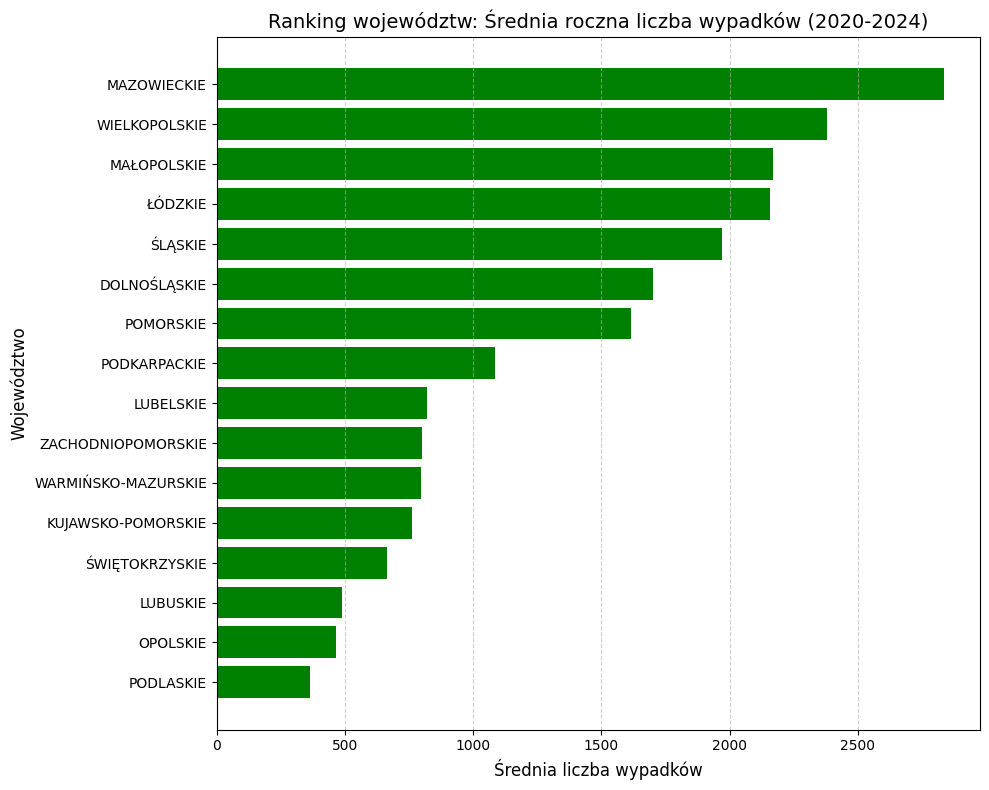

In [49]:
import matplotlib.pyplot as plt

wykres_data = df_srednie.sort_values(by='ogółem', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(wykres_data['Nazwa'], wykres_data['ogółem'], color='green')
plt.title('Ranking województw: Średnia roczna liczba wypadków (2020-2024)', fontsize=14)
plt.xlabel('Średnia liczba wypadków', fontsize=12)
plt.ylabel('Województwo', fontsize=12)

#siatka pomocnicza
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [44]:
wybrana_kat = 'wina pieszych - nieostrożne wejście na jezdnię' 

analiza_woj_piesi = []
df_tylko_woj = df[df['Nazwa'] != 'POLSKA']

for _, row in df_tylko_woj.iterrows():
    lata_kolumny = [f"{wybrana_kat}_{rok}" for rok in range(2020, 2025)]
    dane_seria = row[lata_kolumny].astype(float)
    
    analiza_woj_piesi.append({
        'Województwo': row['Nazwa'],
        'Średnia': dane_seria.mean(),
        'Mediana': dane_seria.median(),
        'Odch. std.': dane_seria.std(),
        'IQR': dane_seria.quantile(0.75) - dane_seria.quantile(0.25),
        'Skośność': dane_seria.skew(),
        'Kurtoza': dane_seria.kurtosis()
    })

ranking_woj_piesi = pd.DataFrame(analiza_woj_piesi).round(3)

ranking_woj_piesi = ranking_woj_piesi.sort_values(by='Średnia', ascending=False)

In [45]:
print(f"STATYSTYKI CZASOWE (2020-2024) DLA: {wybrana_kat.upper()}")
ranking_woj_piesi

STATYSTYKI CZASOWE (2020-2024) DLA: WINA PIESZYCH - NIEOSTROŻNE WEJŚCIE NA JEZDNIĘ


,Województwo,Średnia,Mediana,Odch. std.,IQR,Skośność,Kurtoza
6,MAZOWIECKIE,84.2,83.0,11.100,10.0,1.228,1.532
11,ŚLĄSKIE,83.0,77.0,22.057,17.0,0.696,0.740
5,MAŁOPOLSKIE,81.4,77.0,17.869,13.0,1.190,1.711
4,ŁÓDZKIE,66.6,72.0,17.358,25.0,0.072,-1.838
14,WIELKOPOLSKIE,59.4,58.0,6.025,6.0,1.226,1.229
0,DOLNOŚLĄSKIE,52.2,49.0,6.907,7.0,1.184,0.548
10,POMORSKIE,49.4,45.0,13.502,11.0,1.609,2.560
8,PODKARPACKIE,44.2,46.0,13.065,1.0,-1.168,2.727
2,LUBELSKIE,36.0,35.0,6.782,6.0,1.322,1.785
1,KUJAWSKO-POMORSKIE,27.6,28.0,4.037,3.0,-0.123,0.676


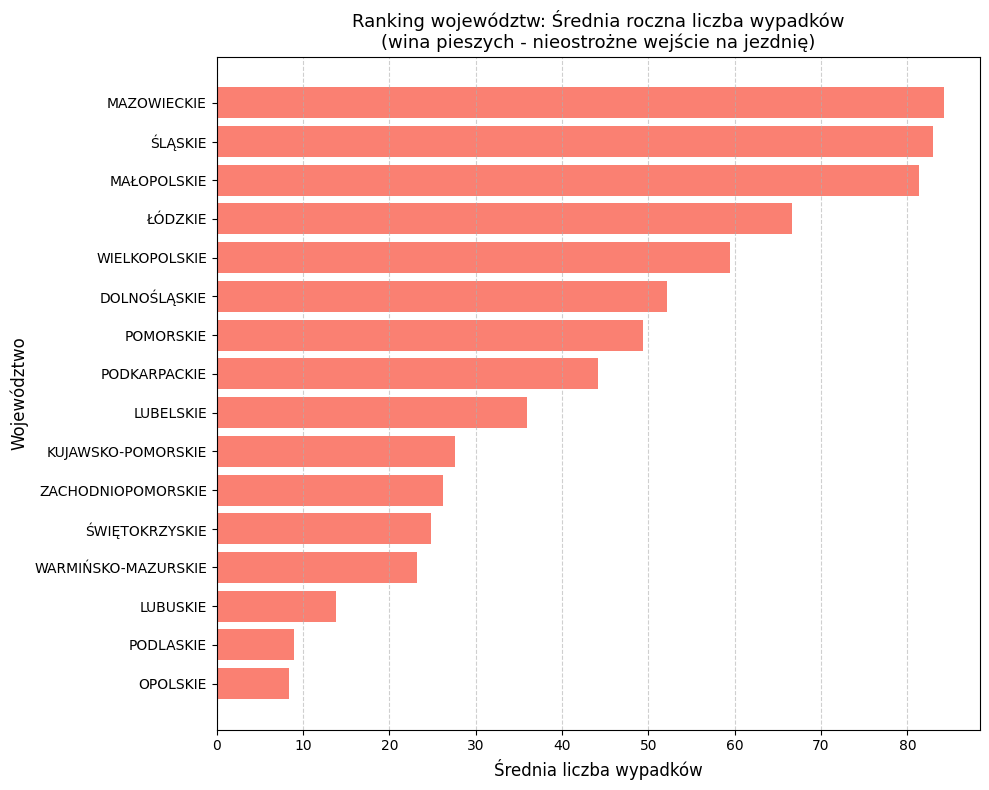

In [52]:
wykres_piesi = ranking_woj_piesi.sort_values(by='Średnia', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(wykres_piesi['Województwo'], wykres_piesi['Średnia'], color='salmon')
plt.title(f'Ranking województw: Średnia roczna liczba wypadków\n({wybrana_kat})', fontsize=13)
plt.xlabel('Średnia liczba wypadków', fontsize=12)
plt.ylabel('Województwo', fontsize=12)

#siatka pomocnicza
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Porównanie wina kierowców i wina pieszych (ogółem)')

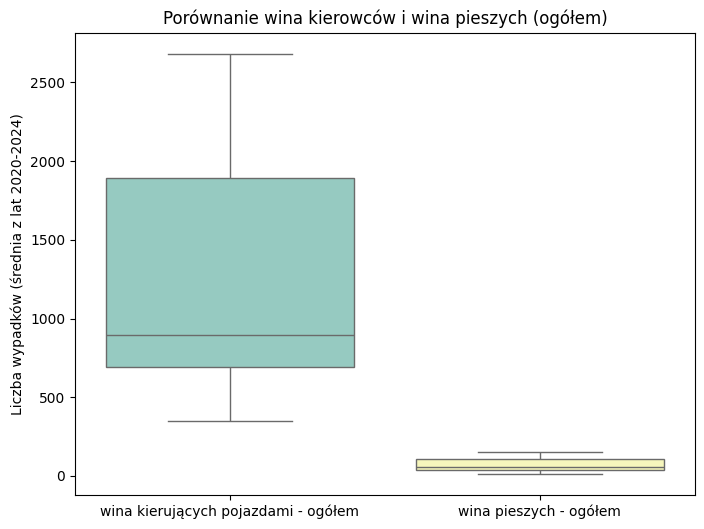

In [54]:
import seaborn as sns

df_boxplot = df_srednie[['wina kierujących pojazdami - ogółem',
                           'wina pieszych - ogółem']]

plt.figure(figsize=(8,6))

# Boxplot - pokazuje rozkład wartości
sns.boxplot(data=df_boxplot,palette="Set3")
plt.ylabel("Liczba wypadków (średnia z lat 2020-2024)")
plt.title("Porównanie wina kierowców i wina pieszych (ogółem)")